# Phase 2: Replication of Card & Krueger (1994)

This notebook replicates the main findings using a Difference-in-Differences (DID) approach.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

## 1. Load Clean Panel Data

In [3]:
panel = pd.read_csv("njmin_panel_clean.csv")
panel.head()

,SHEET,CHAIN,CO_OWNED,STATE,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,PSODA,PFRY,PENTREE,NREGS,NREGS11,wave,treated,post,did,emp
0,46,1,0,0,0,0,0,1,0,0,...,1.03,1.03,0.52,3,3,1,0,0,0,45.0
1,49,2,0,0,0,0,0,1,0,0,...,1.01,0.90,2.35,4,3,1,0,0,0,13.0
2,506,2,1,0,0,0,0,1,0,0,...,0.95,0.74,2.33,3,3,1,0,0,0,10.0
3,56,4,1,0,0,0,0,1,0,0,...,0.87,0.82,1.79,2,2,1,0,0,0,40.0
4,61,4,1,0,0,0,0,1,0,0,...,0.87,0.77,1.65,2,2,1,0,0,0,32.0


In [4]:
panel.columns.tolist()

['SHEET',
 'CHAIN',
 'CO_OWNED',
 'STATE',
 'SOUTHJ',
 'CENTRALJ',
 'NORTHJ',
 'PA1',
 'PA2',
 'SHORE',
 'NCALLS',
 'EMPFT',
 'EMPPT',
 'NMGRS',
 'WAGE_ST',
 'PCTAFF',
 'MEALS',
 'OPEN',
 'HRSOPEN',
 'PSODA',
 'PFRY',
 'PENTREE',
 'NREGS',
 'NREGS11',
 'wave',
 'treated',
 'post',
 'did',
 'emp']

## 2. Data Preparation
We convert key variables to numeric format.

In [5]:
for c in ["EMPFT", "EMPPT", "NMGRS", "WAGE_ST", "PSODA", "PFRY", "PENTREE", "treated", "post", "did", "SHEET"]:
    panel[c] = pd.to_numeric(panel[c], errors="coerce")

In [6]:
panel[["EMPFT", "EMPPT", "NMGRS", "WAGE_ST", "PSODA", "PFRY", "PENTREE"]].dtypes

,0
EMPFT,float64
EMPPT,float64
NMGRS,float64
WAGE_ST,float64
PSODA,float64
PFRY,float64
PENTREE,float64


## 3. Construct FTE Employment

We define full-time equivalent employment (FTE) as:

FTE = EMPFT + 0.5 × EMPPT + NMGRS

In [7]:
panel["fte"] = panel["EMPFT"] + 0.5 * panel["EMPPT"] + panel["NMGRS"]
panel[["EMPFT", "EMPPT", "NMGRS", "fte"]].head()

,EMPFT,EMPPT,NMGRS,fte
0,30.0,15.0,3.0,40.50
1,6.5,6.5,4.0,13.75
2,3.0,7.0,2.0,8.50
3,20.0,20.0,4.0,34.00
4,6.0,26.0,5.0,24.00


## 4. Descriptive Statistics

In [8]:
table2 = panel.groupby(["STATE", "wave"])[["fte", "WAGE_ST", "PSODA", "PFRY", "PENTREE"]].agg(["mean", "std"])
table2

fte              WAGE_ST               PSODA            \
                 mean        std      mean       std      mean       std   
STATE wave                                                                 
0     1     23.331169  11.856283  4.630132  0.351687  0.974675  0.069483   
      2     21.165584   8.276732  4.617465  0.357478  0.859863  0.095299   
1     1     20.408255   9.069872  4.612134  0.346351  1.061508  0.084579   
      2     21.027429   9.293024  5.080849  0.104545  0.960453  0.103518   

                PFRY             PENTREE            
                mean       std      mean       std  
STATE wave                                          
0     1     0.841948  0.087510  1.215065  0.622889  
      2     1.185467  0.577961  3.454545  1.187051  
1     1     0.941487  0.100778  1.347882  0.646141  
      2     1.394727  0.660275  3.646302  1.256073

## 5. Difference in Means

In [9]:
fte_mean_table = panel.groupby(["treated", "post"])["fte"].mean().unstack()
fte_mean_table

post,0,1
treated,,
0,23.331169,21.165584
1,20.408255,21.027429


## 6. Manual DID Calculation

In [10]:
fte_did_value = (fte_mean_table.loc[1, 1] - fte_mean_table.loc[1, 0]) - (fte_mean_table.loc[0, 1] - fte_mean_table.loc[0, 0])
fte_did_value

np.float64(2.784758430955659)

## 7. DID Regression (Robust Standard Errors)

In [11]:
model_fte = smf.ols("fte ~ treated + post + did", data=panel).fit(cov_type="HC1")
print(model_fte.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.447
Date:                Fri, 20 Mar 2026   Prob (F-statistic):              0.228
Time:                        18:32:18   Log-Likelihood:                -2903.0
No. Observations:                 794   AIC:                             5814.
Df Residuals:                     790   BIC:                             5833.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.346     17.337      0.0

## 8. Clustered Standard Errors

In [12]:
reg_data = panel[["fte", "treated", "post", "did", "SHEET"]].dropna().copy()
reg_data["SHEET"] = reg_data["SHEET"].astype(int)
reg_data.head()

,fte,treated,post,did,SHEET
0,40.50,0,0,0,46
1,13.75,0,0,0,49
2,8.50,0,0,0,506
3,34.00,0,0,0,56
4,24.00,0,0,0,61


In [13]:
reg_data.shape

(794, 5)

In [14]:
model_cluster = smf.ols(
    "fte ~ treated + post + did",
    data=reg_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_data["SHEET"]}
)

print(model_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.873
Date:                Fri, 20 Mar 2026   Prob (F-statistic):              0.134
Time:                        18:36:03   Log-Likelihood:                -2903.0
No. Observations:                 794   AIC:                             5814.
Df Residuals:                     790   BIC:                             5833.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.347     17.327      0.0

In [15]:
cluster_result = pd.DataFrame({
    "coef": model_cluster.params,
    "std_err": model_cluster.bse,
    "p_value": model_cluster.pvalues
})

cluster_result.loc[["treated", "post", "did"]]

,coef,std_err,p_value
treated,-2.922913,1.435896,0.041790
post,-2.165584,1.218028,0.075413
did,2.784758,1.306456,0.033045


## 9. Employment Trends Visualization

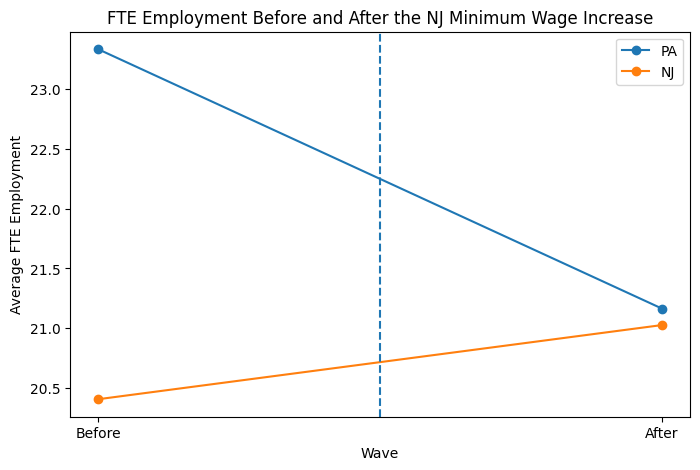

In [16]:
trend = panel.groupby(["STATE", "wave"])["fte"].mean().reset_index()

plt.figure(figsize=(8, 5))

for state, label in [(0, "PA"), (1, "NJ")]:
    subset = trend[trend["STATE"] == state]
    plt.plot(subset["wave"], subset["fte"], marker="o", label=label)

plt.axvline(x=1.5, linestyle="--")
plt.xticks([1, 2], ["Before", "After"])
plt.xlabel("Wave")
plt.ylabel("Average FTE Employment")
plt.title("FTE Employment Before and After the NJ Minimum Wage Increase")
plt.legend()
plt.show()

In [17]:
table2.to_csv("table2_descriptive.csv")
cluster_result.to_csv("did_cluster_results.csv", index=True)

In [18]:
from google.colab import files

files.download("table2_descriptive.csv")
files.download("did_cluster_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Interpretation

The DID estimate is positive, suggesting that the minimum wage increase in New Jersey did not reduce employment in fast-food restaurants.

This result is consistent with Card and Krueger (1994). The clustered standard errors provide more reliable inference by accounting for within-store correlation.